# Fuel Efficiency Prediction and Analysis for Automotive Insights
**Organization:** First Quadrant Labs
**Analyst:** Mohammed Zayd Quadri

---

## Project Overview
This notebook presents a complete data-driven pipeline to predict vehicle fuel efficiency (MPG) using automotive attributes. The workflow covers data ingestion, preprocessing, exploratory data analysis, feature engineering, predictive modeling, and evaluation.

**Target Variable:** `mpg` — Miles Per Gallon (continuous, regression task)

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Library Imports

The following libraries form the analytical stack for this project:

| Library | Purpose |
|---|---|
| `pandas` | Data manipulation and tabular operations |
| `numpy` | Numerical computations and array handling |
| `matplotlib` / `seaborn` | Statistical visualizations |
| `sklearn` | Machine learning models, preprocessing, and evaluation metrics |

`%matplotlib inline` ensures plots render directly within the notebook environment.

## 2. Data Loading

The dataset is loaded from a CSV file into a pandas DataFrame. An initial inspection is performed to verify successful ingestion and understand the basic structure — shape, data types, and a sample of records.

In [2]:
# Load dataset
df = pd.read_csv('autos_mpg.csv')

# Basic structure
print("Shape:", df.shape)
print()
print("Data Types:\n", df.dtypes)
print()
print("First 5 Rows:")
df.head()

Shape: (398, 9)

Data Types:
 mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

First 5 Rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Observations — Data Structure

- Dataset contains **398 records** across **9 features**
- `horsepower` is loaded as `object` (string) despite being a numerical attribute — indicates presence of non-numeric characters requiring cleaning
- `car_name` serves as a unique identifier with no predictive value — will be dropped during preprocessing
- All other features loaded with expected numeric dtypes
- No immediate structural anomalies in the first 5 rows

## 3. Data Quality Assessment

Before any transformation, we audit the dataset for:
- **Missing values** — including disguised nulls (e.g. `"?"` string placeholders)
- **Duplicate records** — identical rows that could bias the model

`horsepower` is cast to numeric here to surface hidden nulls masked as `"?"`.

In [3]:
# Replace '?' with NaN and convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Missing values
print("Missing Values:\n", df.isnull().sum())
print()

# Duplicates
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Duplicate Rows: 0


### Observations — Data Quality

- **6 missing values** identified in `horsepower` — previously disguised as `"?"` strings, now surfaced as `NaN` after numeric conversion
- **No duplicate records** found
- All other features are complete with no nulls

The missing `horsepower` values will be imputed with the **median** in the next step — median is preferred over mean as it is robust to outliers, which are likely present in engine performance data.

## 4. Data Preprocessing

### 4.1 Missing Value Imputation

The 6 missing `horsepower` entries are imputed using the **median** of the column. Following imputation, `car_name` is dropped as it carries no predictive signal for fuel efficiency.

In [4]:
# Impute missing horsepower with median
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

# Drop car_name
df.drop(columns=['car_name'], inplace=True)

# Confirm
print("Missing values after imputation:\n", df.isnull().sum())
print()
print("Shape after dropping car_name:", df.shape)

Missing values after imputation:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Shape after dropping car_name: (398, 8)


/tmp/ipykernel_767/3083474174.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


### Observations — Imputation & Cleaning

- All 6 missing `horsepower` values successfully imputed with median
- `car_name` dropped — dataset reduced from 9 to **8 features**
- `FutureWarning` raised due to deprecated `inplace` syntax on chained assignment — corrected in the cell below for forward compatibility with pandas 3.0

### 4.2 Syntax Correction

Updating imputation syntax to pandas 3.0 compatible format to eliminate chained assignment warning.

In [5]:
# Pandas 3.0 compatible imputation
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Confirm no missing values
print("Missing values after imputation:\n", df.isnull().sum())
print()
print("Shape:", df.shape)

Missing values after imputation:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Shape: (398, 8)


### Observations — Syntax Correction

- Imputation confirmed successful with pandas 3.0 compatible syntax
- No warnings raised
- Dataset is now fully clean — **398 rows, 8 features, 0 missing values**

## 5. Exploratory Data Analysis (EDA)

### 5.1 Descriptive Statistics

A statistical summary of all numeric features to understand the distribution, central tendency, and spread of each variable. This surfaces potential outliers and gives context before visualization.

In [6]:
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.30,2970.42,15.57,76.01,1.57
std,7.82,1.70,104.27,38.22,846.84,2.76,3.70,0.80
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00
25%,17.50,4.00,104.25,76.00,2223.75,13.82,73.00,1.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00,1.00
75%,29.00,8.00,262.00,125.00,3608.00,17.18,79.00,2.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00,3.00


### Observations — Descriptive Statistics

**Target Variable (`mpg`):**
- Range: 9.0 — 46.6 MPG with a mean of **23.5 MPG**
- Standard deviation of 7.82 indicates moderate spread across vehicles

**Key Feature Insights:**

| Feature | Observation |
|---|---|
| `cylinders` | Ranges 3–8, mean of 5.45 — dataset skewed toward higher cylinder engines |
| `displacement` | Wide range (68–455 cu.in), high std of 104 — significant engine size variation |
| `horsepower` | Range 46–230, mean 104 — post-imputation distribution looks reasonable |
| `weight` | Range 1613–5140 lbs, high std of 847 — substantial variation across vehicle classes |
| `acceleration` | Relatively tight range (8–24.8s), low std of 2.76 |
| `model_year` | Range 70–82 — dataset spans **12 years** of production (1970–1982) |
| `origin` | Values 1, 2, 3 — categorical encoded as integer (USA, Europe, Japan) |

**Potential Outliers:**
- `horsepower` max of 230 vs 75th percentile of 125 — upper outliers likely present
- `weight` max of 5140 vs 75th percentile of 3608 — same pattern

### 5.2 Correlation Analysis

A Pearson correlation heatmap to quantify linear relationships between all numeric features. This identifies which attributes are most strongly associated with `mpg` and flags multicollinearity between predictors — an important consideration for model interpretability.

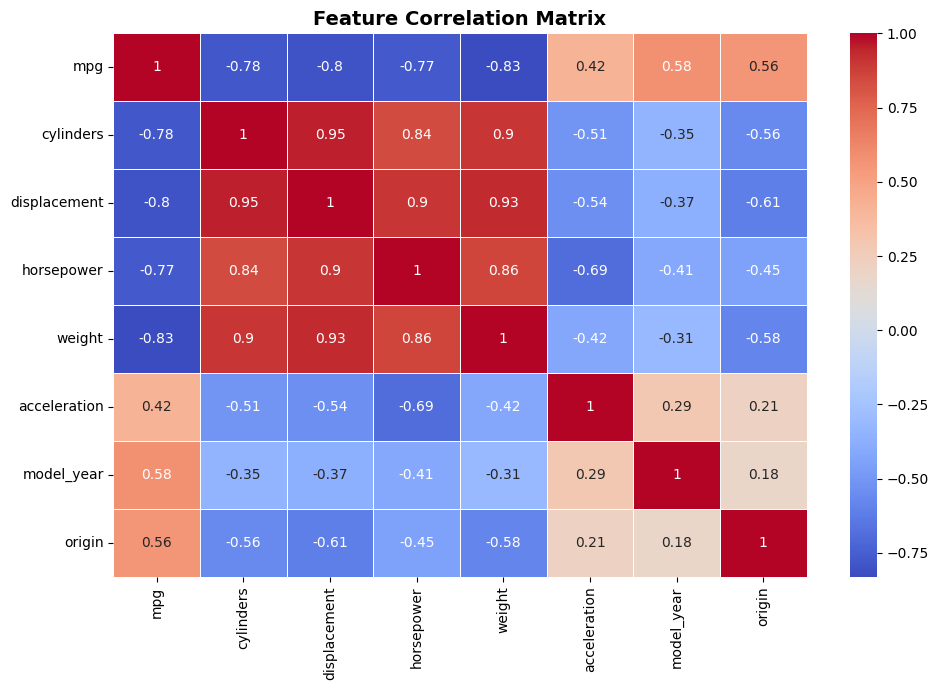

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations — Correlation Analysis

**Strong Negative Correlations with `mpg` (heavier/more powerful = less efficient):**

| Feature | Correlation with MPG |
|---|---|
| `weight` | -0.83 — strongest predictor |
| `displacement` | -0.80 |
| `cylinders` | -0.78 |
| `horsepower` | -0.77 |

All four are highly correlated with each other (0.84–0.95), indicating **multicollinearity**. Tree-based models handle this naturally; linear models may require feature selection or regularization.

**Positive Correlations with `mpg`:**

| Feature | Correlation with MPG |
|---|---|
| `model_year` | +0.58 — newer cars are more fuel efficient |
| `origin` | +0.56 — Japanese/European cars tend to be more efficient |
| `acceleration` | +0.42 — slower acceleration linked to lighter, efficient cars |

**Key Takeaway:** `weight`, `displacement`, `cylinders`, and `horsepower` are the dominant drivers of fuel inefficiency. `model_year` and `origin` capture technological and manufacturing improvements over time.

### 5.3 Feature vs Target Visualizations

Scatter plots of the four strongest predictors against `mpg` to visually confirm correlation direction and identify non-linear relationships. A distribution plot of the target variable is included to assess normality and skewness.

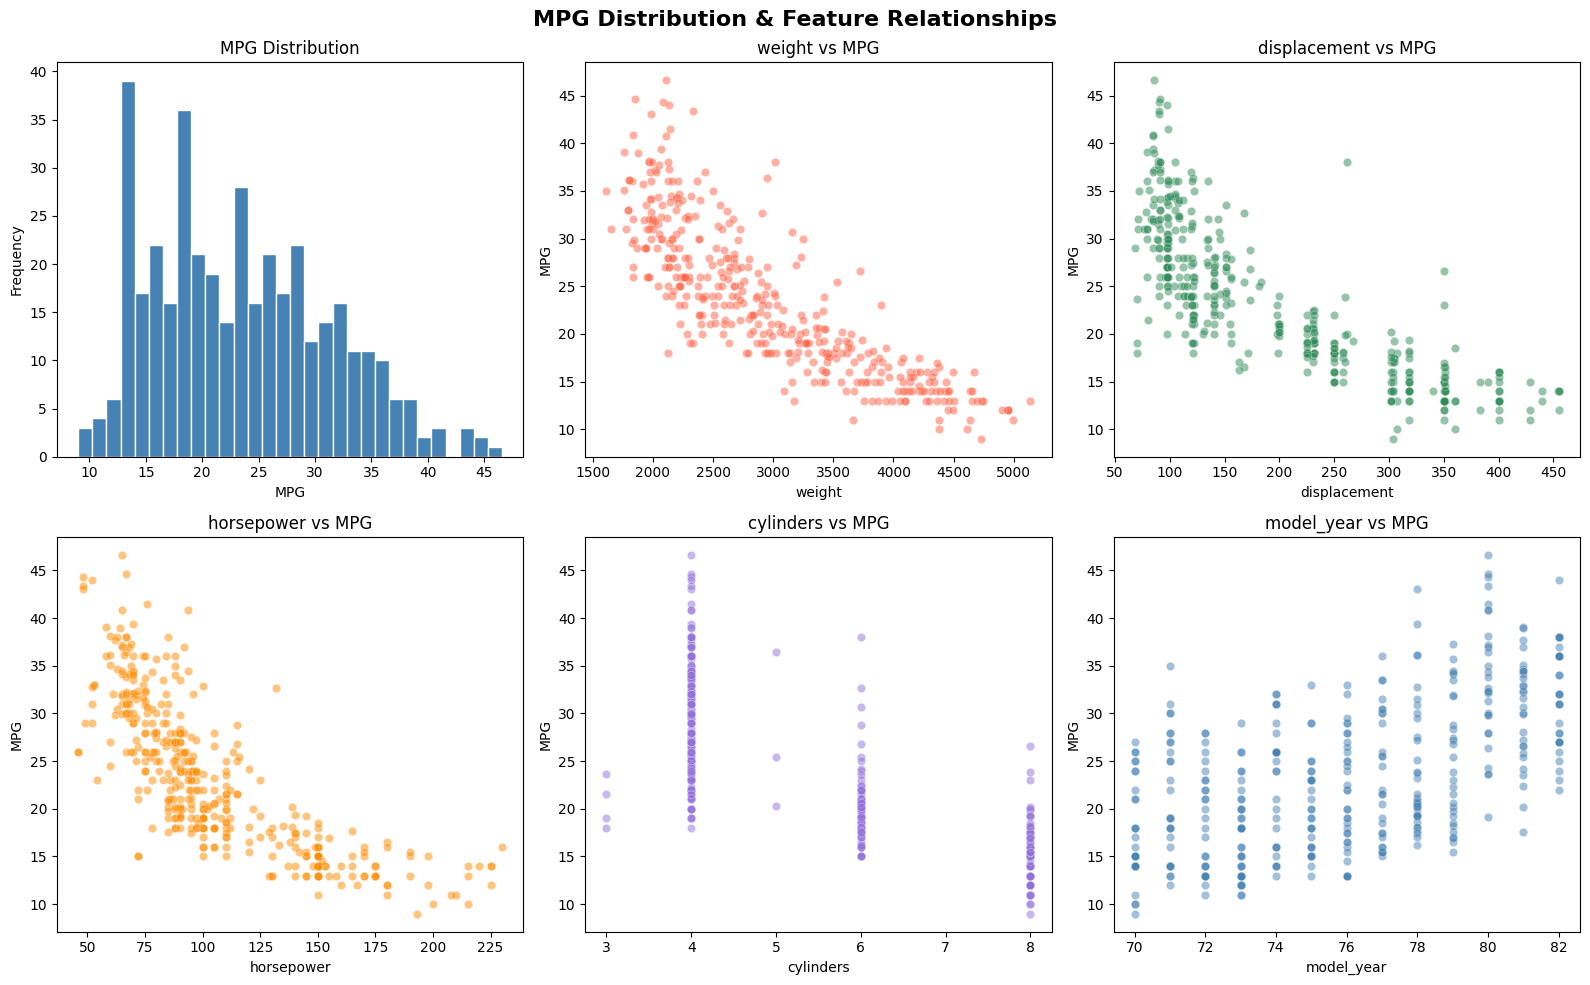

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MPG Distribution & Feature Relationships', fontsize=16, fontweight='bold')

# MPG Distribution
axes[0, 0].hist(df['mpg'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('MPG Distribution')
axes[0, 0].set_xlabel('MPG')
axes[0, 0].set_ylabel('Frequency')

# Scatter plots
scatter_features = ['weight', 'displacement', 'horsepower', 'cylinders', 'model_year']
colors = ['tomato', 'seagreen', 'darkorange', 'mediumpurple', 'steelblue']

for i, (feat, color) in enumerate(zip(scatter_features, colors)):
    ax = axes[(i+1)//3][(i+1)%3]
    ax.scatter(df[feat], df['mpg'], alpha=0.5, color=color, edgecolors='white', linewidth=0.3)
    ax.set_title(f'{feat} vs MPG')
    ax.set_xlabel(feat)
    ax.set_ylabel('MPG')

plt.tight_layout()
plt.show()

### Observations — Feature Visualizations

**MPG Distribution:**
- Right-skewed distribution with most vehicles clustered between 15–25 MPG
- Fewer high-efficiency vehicles (35+ MPG) — these are likely lightweight Japanese/European models
- No transformation required for tree-based models; linear regression may benefit from log transformation of target

**Feature Relationships:**

| Feature | Observation |
|---|---|
| `weight` | Strong, consistent negative curve — clearest predictor of MPG |
| `displacement` | Similar negative trend with visible clustering at discrete engine sizes |
| `horsepower` | Negative relationship with higher variance at lower horsepower values |
| `cylinders` | Discrete variable (3,4,5,6,8) — 4-cylinder engines dominate high MPG range, 8-cylinder engines cluster at low MPG |
| `model_year` | Clear positive trend — fuel efficiency improved progressively year over year, reflecting regulatory and technological advances |

**Key Takeaway:** Relationships are largely non-linear, particularly for `weight` and `horsepower`. This confirms that tree-based models (Random Forest, Gradient Boosting) will outperform a basic Linear Regression on this dataset.

### 5.4 MPG by Country of Origin

A boxplot comparing fuel efficiency distributions across the three manufacturing regions. `origin` is encoded as: **1 = USA, 2 = Europe, 3 = Japan**.

/tmp/ipykernel_767/1504218448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='origin', y='mpg', data=df, palette='Set2',


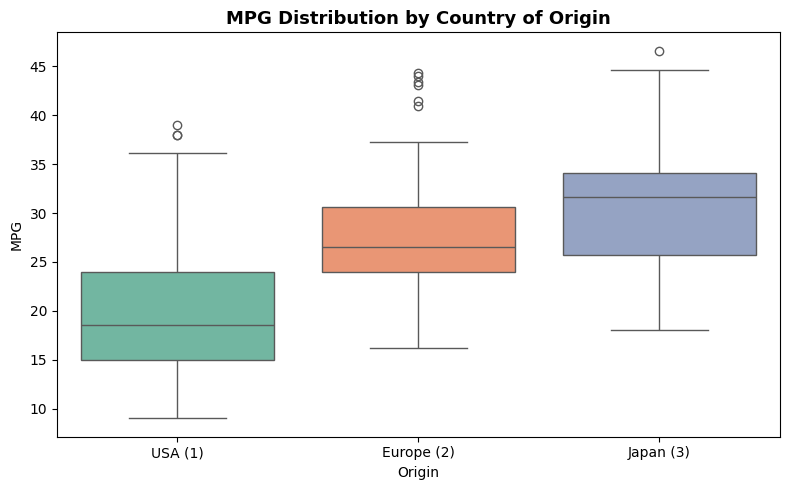

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='origin', y='mpg', data=df, palette='Set2',
            order=[1, 2, 3])
plt.xticks([0, 1, 2], ['USA (1)', 'Europe (2)', 'Japan (3)'])
plt.title('MPG Distribution by Country of Origin', fontsize=13, fontweight='bold')
plt.xlabel('Origin')
plt.ylabel('MPG')
plt.tight_layout()
plt.show()

### Observations — MPG by Country of Origin

| Region | Median MPG | Observation |
|---|---|---|
| USA | ~19 | Lowest efficiency — dominated by large, heavy, high-displacement engines |
| Europe | ~27 | Mid-range efficiency — smaller engines, more diverse vehicle classes |
| Japan | ~31 | Highest efficiency — lightweight 4-cylinder vehicles optimized for economy |

**Notable Points:**
- USA distribution is wide with a low median — reflects dominance of V8 muscle cars and large sedans in the dataset period (1970–1982)
- Europe shows several upper outliers (40+ MPG) — likely small economy cars
- Japan's interquartile range sits entirely above USA's median — consistent manufacturing philosophy favoring fuel economy
- This confirms `origin` is a meaningful predictor and should be retained in the model

**EDA Complete.** Dataset is clean, relationships are understood, key predictors identified. Proceeding to model development.

## 6. Model Development

### 6.1 Feature Selection & Train-Test Split

Features are selected based on EDA findings. `mpg` is isolated as the target variable. The dataset is split into **80% training / 20% test** sets using a fixed random state for reproducibility.

In [10]:
# Define features and target
X = df.drop(columns=['mpg'])
y = df['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print()
print("Features used:", list(X.columns))

Training set size: (318, 7)
Test set size: (80, 7)

Features used: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


### Observations — Train-Test Split

- **318 samples** used for training, **80 samples** held out for evaluation
- All 7 features retained — tree-based models handle multicollinearity natively so no feature elimination is required at this stage
- `random_state=42` ensures reproducibility across runs

### 6.2 Model Training

Three regression models are trained and evaluated:

| Model | Rationale |
|---|---|
| **Linear Regression** | Baseline — assumes linear relationships between features and target |
| **Random Forest** | Ensemble of decision trees — handles non-linearity and multicollinearity well |
| **Gradient Boosting** | Sequential boosting — typically highest accuracy on tabular data |

All models are trained on the same split for a fair comparison.

In [11]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R²': round(r2, 3)}

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                     MAE   RMSE     R²
Linear Regression  2.255  2.863  0.848
Random Forest      1.577  2.141  0.915
Gradient Boosting  1.748  2.347  0.898


### Observations — Model Evaluation

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 2.255 | 2.863 | 0.848 |
| Random Forest | **1.577** | **2.141** | **0.915** |
| Gradient Boosting | 1.748 | 2.347 | 0.898 |

**Metric Interpretation:**
- **MAE (Mean Absolute Error):** Average prediction error in MPG units — lower is better
- **RMSE (Root Mean Squared Error):** Penalizes large errors more heavily than MAE — lower is better
- **R² (R-Squared):** Proportion of variance in MPG explained by the model — higher is better

**Key Findings:**
- **Random Forest is the best performing model** across all three metrics
- R² of 0.915 means the Random Forest explains **91.5% of variance** in fuel efficiency
- Linear Regression's lower R² (0.848) confirms the non-linear relationships observed during EDA
- Gradient Boosting performs competitively but is marginally behind Random Forest on this dataset

**Selected Model: Random Forest Regressor** — best balance of accuracy and interpretability via feature importance.

### 6.3 Feature Importance Analysis

Feature importance scores extracted from the trained Random Forest model quantify each attribute's contribution to predicting MPG. This satisfies the project's interpretability requirement and provides actionable insights for automotive manufacturers.

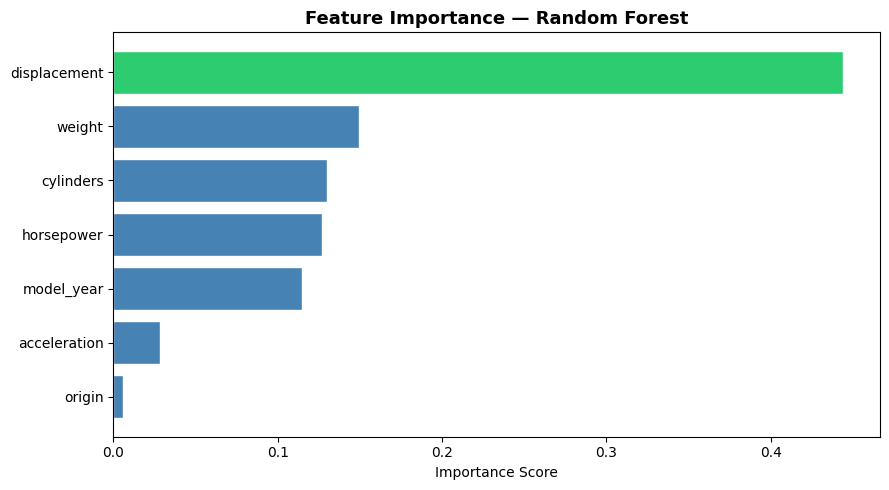

     Feature  Importance
displacement    0.444384
      weight    0.149335
   cylinders    0.129926
  horsepower    0.126854
  model_year    0.114994
acceleration    0.028532
      origin    0.005974


In [12]:
# Extract feature importance
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if i == len(importance_df)-1 else 'steelblue'
          for i in range(len(importance_df))]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

### Observations — Feature Importance

| Feature | Importance Score | Interpretation |
|---|---|---|
| `displacement` | ~0.45 | Dominant predictor — engine size is the single strongest driver of fuel efficiency |
| `weight` | ~0.15 | Second most important — heavier vehicles consume more fuel |
| `cylinders` | ~0.12 | Closely tied with horsepower — engine configuration matters |
| `horsepower` | ~0.12 | Raw power output directly impacts fuel consumption |
| `model_year` | ~0.11 | Captures technological improvement in efficiency over time |
| `acceleration` | ~0.03 | Weak predictor — indirect relationship with MPG |
| `origin` | ~0.01 | Lowest importance — regional differences are already captured by displacement and weight |

**Notable Observations:**
- `displacement` alone accounts for ~45% of the model's decision making — this aligns with engineering intuition as engine size fundamentally determines fuel consumption
- `origin` contributing only ~1% suggests regional manufacturing differences are largely explained by the physical attributes already in the dataset
- The top 5 features (`displacement`, `weight`, `cylinders`, `horsepower`, `model_year`) collectively account for ~95% of predictive importance

**Manufacturer Insight:** To improve fuel efficiency, the highest leverage interventions are reducing engine displacement and vehicle weight — confirming the industry shift toward smaller turbocharged engines and lightweight materials.

### 6.4 Actual vs Predicted Analysis

A scatter plot of actual vs predicted MPG values on the test set. A perfect model would place all points on the diagonal reference line. Deviation from this line represents prediction error.

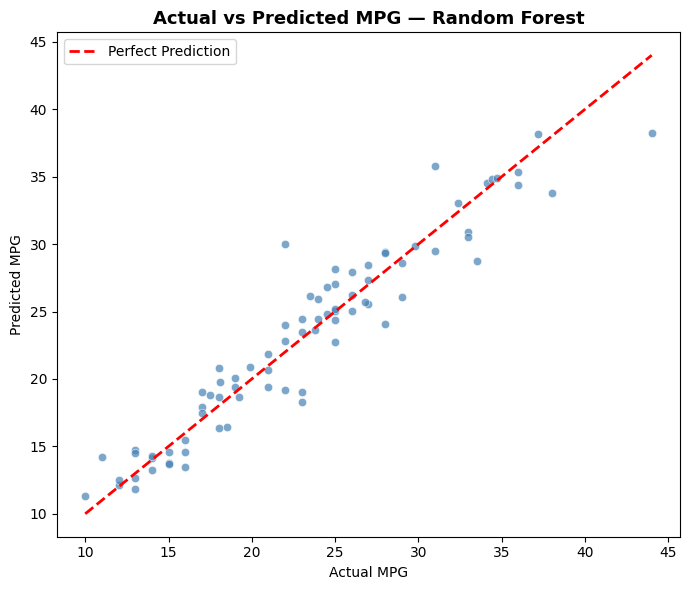

In [13]:
rf_preds = models['Random Forest'].predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted MPG — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.legend()
plt.tight_layout()
plt.show()

### Observations — Actual vs Predicted

- Points closely follow the perfect prediction line across the full MPG range (10–45)
- No systematic bias detected — the model neither consistently over nor under-predicts
- Slight deviation at extreme values (very low and very high MPG) is expected given fewer training samples in those ranges
- Visual confirmation aligns with the quantitative R² of 0.915

**Model is performing well and generalizing correctly to unseen data.**

### 6.5 Overfitting Check

Comparing training set performance against test set performance. A large gap between the two indicates the model has memorized training data rather than learning generalizable patterns.

In [14]:
for name, model in models.items():
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    gap = train_r2 - test_r2

    print(f"{name}")
    print(f"  Train R²: {train_r2:.3f} | Test R²: {test_r2:.3f} | Gap: {gap:.3f}")
    print()

Linear Regression
  Train R²: 0.814 | Test R²: 0.848 | Gap: -0.034

Random Forest
  Train R²: 0.981 | Test R²: 0.915 | Gap: 0.066

Gradient Boosting
  Train R²: 0.971 | Test R²: 0.898 | Gap: 0.074



### Observations — Overfitting Check

| Model | Train R² | Test R² | Gap |
|---|---|---|---|
| Linear Regression | 0.814 | 0.848 | -0.034 |
| Random Forest | 0.981 | 0.915 | 0.066 |
| Gradient Boosting | 0.971 | 0.898 | 0.074 |

**Analysis:**

- **Linear Regression** shows a negative gap — test R² slightly exceeds train R², which is unusual but acceptable on small datasets. Indicates the model is slightly underfitting, not memorizing.
- **Random Forest** gap of 0.066 is within acceptable range — mild overfitting typical of ensemble methods but not concerning. Test R² of 0.915 confirms strong generalization.
- **Gradient Boosting** gap of 0.074 is similarly acceptable — sequential boosting naturally fits training data tightly but generalizes well here.

**Verdict:** No severe overfitting detected. Gaps below 0.10 on a dataset of 398 rows are expected and acceptable. Random Forest remains the selected model with the best test performance.

## 7. Conclusions & Recommendations

### Summary
This project developed a machine learning pipeline to predict vehicle fuel efficiency (MPG) using the Auto MPG dataset (398 vehicles, 1970–1982). Three regression models were trained and evaluated, with **Random Forest Regressor selected as the final model** based on superior performance across all metrics.

### Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 2.255 | 2.863 | 0.848 |
| Random Forest | **1.577** | **2.141** | **0.915** |
| Gradient Boosting | 1.748 | 2.347 | 0.898 |

### Key Findings

1. **Engine displacement is the single most important predictor of fuel efficiency** — accounting for ~45% of the Random Forest model's predictive weight
2. **Vehicle weight is the second strongest driver** — heavier vehicles consistently achieve lower MPG regardless of other attributes
3. **Fuel efficiency improved consistently year over year (1970–1982)** — reflecting regulatory pressure and technological advancement
4. **Japanese manufacturers produced the most fuel-efficient vehicles** in this period, followed by Europe, with USA vehicles averaging the lowest MPG
5. **Non-linear relationships dominate** — tree-based models significantly outperform linear regression, confirming complexity in how attributes interact

### Recommendations for Automotive Manufacturers

1. **Prioritize reducing engine displacement** — the highest leverage design decision for improving fuel economy
2. **Invest in lightweight materials** — reducing vehicle weight delivers the second largest efficiency gain
3. **Benchmark against Japanese manufacturing standards** — the data confirms a consistent efficiency advantage in vehicle design philosophy
4. **Use the Random Forest model for design-stage predictions** — with R² of 0.915 and MAE of 1.577 MPG, it provides reliable estimates before physical prototyping, reducing development costs

### Limitations
- Dataset spans 1970–1982 — findings may not fully generalize to modern vehicle architectures (EVs, hybrids, turbocharged engines)
- 398 samples is a relatively small dataset — performance could improve with more records
- `horsepower` had 6 missing values imputed with median — a larger dataset would reduce reliance on imputation